# ANALYSIS FOR CARRIS DATA - PILOT 4 DATASET

In [7]:
start_date="2023-01-01"
end_date="2027-01-01"
#start_date="2025-01-01"
#end_date="2025-07-31"

In [8]:
import common as common
import common_test as common_test

In [9]:
import json

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
API_SERVER="https://api.cssboost.particle-summary.pt"

In [12]:
token="..."

In [13]:
# check valid token
ENDPOINT_USER=API_SERVER+"/rest-auth/user"
(result, data)=common.get_data(ENDPOINT_USER, token, None)

-- get from  https://api.cssboost.particle-summary.pt/rest-auth/user
-- data GET OK.


In [14]:
if result == 200:
    print("-- result OK ", result, data)
else:
    raise SystemExit("-- token invalid? result NOK. code=", result)


-- result OK  200 {'pk': 2, 'username': 'particle+admin@particle-summary.pt', 'email': 'particle+admin@particle-summary.pt', 'first_name': 'particlesummary', 'last_name': 'User', 'person_external_id': '5813eb25-0e31-4f09-9c45-56e01697498b'}


# Pilot Analysis

This initializes the pilot and dataset of interst to perform queries.

In [15]:
PILOT="pilot_4"

In [16]:
DATASET="pilot_4_dataset_1"

In [17]:
ENDPOINT_PILOT=API_SERVER+"/pilots/"+PILOT

In [18]:
ENDPOINT_DATASET=API_SERVER+"/pilots/"+PILOT+"/datasets/"+DATASET

## Basic operations - get pilot and related datasets entities

This set performs basic GET operations to retrieve pilot and dataset information.

In [19]:
(result, data)=common.get_data(ENDPOINT_PILOT, token, None)

-- get from  https://api.cssboost.particle-summary.pt/pilots/pilot_4
-- data GET OK.


In [20]:
print(data)

{'external_id': 'pilot_4', 'name': 'Pilot 4', 'description': 'Pilot 4: Public Transport Vehicle Recycling and Valorisation CSS.'}


In [21]:
(result, data)=common.get_data(ENDPOINT_PILOT+"/datasets", token, None)

-- get from  https://api.cssboost.particle-summary.pt/pilots/pilot_4/datasets
-- data GET OK.


In [22]:
print(data)

{'items': [{'external_id': 'pilot_4_dataset_1', 'name': 'CARRIS Operations Data', 'description': 'Dataset from CARRIS operations: BUS distances, energy consumption and 12v batteries.', 'sharing_policy': 'CLOSED', 'start_date': None, 'end_date': None, 'duration': None, 'groups': [], 'roles': []}], 'count': 1}


In [23]:
(result, data)=common.get_data(ENDPOINT_DATASET, token, None)

-- get from  https://api.cssboost.particle-summary.pt/pilots/pilot_4/datasets/pilot_4_dataset_1
-- data GET OK.


In [24]:
print(data)

{'external_id': 'pilot_4_dataset_1', 'name': 'CARRIS Operations Data', 'description': 'Dataset from CARRIS operations: BUS distances, energy consumption and 12v batteries.', 'sharing_policy': 'CLOSED', 'start_date': None, 'end_date': None, 'duration': None, 'groups': [], 'roles': []}


## Properties data

Generated data can be related with physical properties, involving metrics and units.  These need to be setup.

The list of ALL available properties in DAMS can be retrieved from the endpoint "/properties" as follows.

For a more selective search, see report sources.

In [48]:
ENDPOINT_PROPERTIES=API_SERVER+"/properties"

In [49]:
(result, properties)=common.get_data(ENDPOINT_PROPERTIES, token, None)

-- get from  https://api.cssboost.particle-summary.pt/properties
-- data GET OK.


In [50]:
#print(properties)

In [28]:
# add unit
for prop in properties:
    prop["unit"]=prop["keys"][0]["unit"]
df_prop = pd.DataFrame(properties).reindex(columns=["code", "value_type", "unit"]) #["code", "value_type"]
print(df_prop)

                       code               value_type             unit
0                PARAM00001                       pH                1
1                PARAM00006   Total Suspended Solids             mg/l
2                PARAM00007                      BOD             mg/l
3                PARAM00008                      COD             mg/l
4                PARAM00032    Total Phosphorus (TP)             mg/l
5                PARAM00033           Ammonium (NH4)             mg/l
6                PARAM00034                  Nitrite             mg/l
7                PARAM00035           Nitrate (NO3⁻)             mg/l
8                PARAM00036             Oil & Grease             mg/l
9                PARAM00037       Total Hydrocarbons             mg/l
10               PARAM00042        Total Surfactants             mg/l
11               PARAM00050                   E.Coli             mg/l
12               PARAM00052      Total Nitrogen (TN)             mg/l
13               PAR

<Axes: >

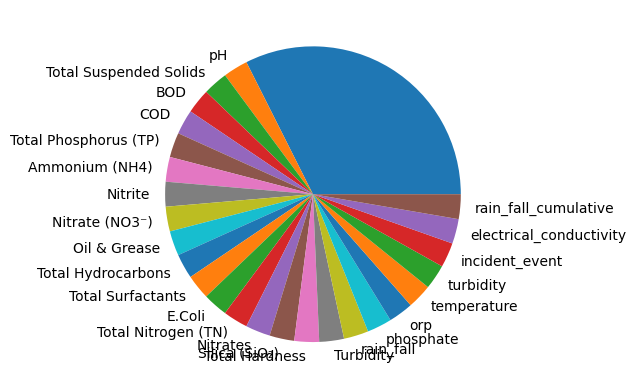

In [29]:
df_prop['value_type'].value_counts().plot(kind='pie')

# CARRIS PROPERTIES

In [30]:
source_properties = [
    "bus_diesel_number",
    "bus_gas_number",
    "bus_electrical_number",
    "fuel_cost_per_kWh",
    "fuel_cost_per_Nm3",
    "fuel_cost_per_L",
    "bus_energy_cost",
    "particles_emissions",
    "nox_emissions",
    "co2_emissions",
    "tep_per_distance",
    "tep",
    "immobilization_rate",
    "failure_rate",
    "energy_consumption_Nm3",
    "energy_consumption_L",
    "energy_consumption_kWh",
    "distance_km",
]

In [31]:
eol_properties = [
    "bus_number",
    "weight"
]

# REPORT-SOURCE relations

This set retrieves the list of available report sources in the dataset.

In [51]:
print("- PILOT:", PILOT, "\n- DATASET:", DATASET)

- PILOT: pilot_4 
- DATASET: pilot_4_dataset_1


In [52]:
ENDPOINT_DATASET_REPORT=API_SERVER+"/pilots/"+PILOT+"/datasets/"+DATASET+"/data-report"

In [55]:
(result, dataset_report)=common.get_data(ENDPOINT_DATASET_REPORT, token, None)
#print(dataset_report)

-- get from  https://api.cssboost.particle-summary.pt/pilots/pilot_4/datasets/pilot_4_dataset_1/data-report
-- data GET OK.


In [56]:
print(dataset_report)

{'items': [{'external_id': 'pilot_4_dataset_1_EOL_BUS', 'name': 'EOL_BUS', 'description': 'Reports related with Buses reaching End of Life', 'source_external_id': 'pilot_4_dataset_1_EOL_BUS', 'source': {'name': 'EoL Bus', 'state': 'ACTIVE', 'valueType': 'PUBLIC', 'macAddress': None, 'serialNumber': None, 'deviceId': 'EOL_BUS', 'externalId': 'EOL_BUS', 'deviceType': 'report_source'}}, {'external_id': 'pilot_4_dataset_1_MAN_GNC_BUS', 'name': 'MAN_GNC_BUS', 'description': 'Reports related with MAN 18.310 GNC', 'source_external_id': 'pilot_4_dataset_1_MAN_GNC_BUS', 'source': {'name': 'MAN 18.310 GNC Natural Gas Bus', 'state': 'ACTIVE', 'valueType': 'PUBLIC', 'macAddress': None, 'serialNumber': None, 'deviceId': 'MAN_GNC_BUS', 'externalId': 'MAN_GNC_BUS', 'deviceType': 'report_source'}}, {'external_id': 'pilot_4_dataset_1_VOLVO_DIESEL_BUS', 'name': 'VOLVO_DIESEL_BUS', 'description': 'Reports related with VOLVO B7R MK3', 'source_external_id': 'pilot_4_dataset_1_VOLVO_DIESEL_BUS', 'source': {

In [54]:
d=[]
for dr in dataset_report["items"]:
    d.append(dr["source"])
df_dataset_source = pd.DataFrame(d).reindex(columns=["name", "deviceType"])
print(df_dataset_source)

                             name     deviceType
0                         EoL Bus  report_source
1  MAN 18.310 GNC Natural Gas Bus  report_source
2        VOLVO B7R MK3 Diesel Bus  report_source
3         CAETANO E. Electric Bus  report_source
4      DS-12V_BATTERY-REPLACEMENT  report_source
5                   BUS DISTANCES  report_source
6              ENERGY CONSUMPTION  report_source


## Report source properties

Report sources can contain data related with one or more properties. Properties can be added to a report source in a dynamic way.

As such, it cannot be know in configuration time which properties a report source contains. 

As such, it is necessary to query which properties a report source contains. 

The endpoint needs the id of the report_source, which can be extracted from the list of sources associated with the dataset.

From the previous example: 

```
{'external_id': 'pilot_4_dataset_1_MAN_GNC_BUS', 'name': 'MAN_GNC_BUS', 'description': 'Reports related with MAN 18.310 GNC', 'source_external_id': 'pilot_4_dataset_1_MAN_GNC_BUS', 'source': {'name': 'MAN 18.310 GNC Natural Gas Bus', 'state': 'ACTIVE', 'valueType': 'PUBLIC', 'macAddress': None, 'serialNumber': None, 'deviceId': 'MAN_GNC_BUS', 'externalId': 'MAN_GNC_BUS', 'deviceType': 'report_source'}}
```

The source id is under `externalId` , thus `MAN_GNC_BUS`

Note that a `start_date` and a `end_date` (format `YYYY-MM-DD`) or an `interval` (format int+time-duration e.g., `1y` for one year) must be provided.

Examples for both cases are given below.

In [62]:
ENDPOINT_REPORT_SOURCE_PROPERTIES=API_SERVER+"/data-reports/%s/properties"

In [65]:
ENDPOINT_REPORT_SOURCE_PROPERTIES_FOR_SOURCE=ENDPOINT_REPORT_SOURCE_PROPERTIES % "MAN_GNC_BUS"
(result, data) = common.get_data(ENDPOINT_REPORT_SOURCE_PROPERTIES_FOR_SOURCE+"?start_date=2025-01-01&end_date=2025-12-31", token, None)
print(data)

-- get from  https://api.cssboost.particle-summary.pt/data-reports/MAN_GNC_BUS/properties?start_date=2025-01-01&end_date=2025-12-31
-- data GET OK.
[{'code': 'bus_number', 'value_type': None, 'keys': [{'code': 'value', 'value_min': None, 'value_max': None, 'precision': 0, 'unit': '1'}]}, {'code': 'distance_km', 'value_type': None, 'keys': [{'code': 'value', 'value_min': None, 'value_max': None, 'precision': 0, 'unit': 'km'}]}, {'code': 'energy_consumption_Nm3', 'value_type': None, 'keys': [{'code': 'value', 'value_min': None, 'value_max': None, 'precision': 0, 'unit': 'Nm3'}]}, {'code': 'failure_rate', 'value_type': None, 'keys': [{'code': 'value', 'value_min': None, 'value_max': None, 'precision': 0, 'unit': 'total/10_1000km'}]}, {'code': 'immobilization_rate', 'value_type': None, 'keys': [{'code': 'value', 'value_min': None, 'value_max': None, 'precision': 0, 'unit': '%'}]}, {'code': 'tep', 'value_type': None, 'keys': [{'code': 'value', 'value_min': None, 'value_max': None, 'precisio

In [61]:
ENDPOINT_REPORT_SOURCE_PROPERTIES=API_SERVER+"/data-reports/%s/properties"

In [66]:
ENDPOINT_REPORT_SOURCE_PROPERTIES_FOR_SOURCE=ENDPOINT_REPORT_SOURCE_PROPERTIES % "MAN_GNC_BUS"
(result, data) = common.get_data(ENDPOINT_REPORT_SOURCE_PROPERTIES_FOR_SOURCE+"?interval=1y", token, None)
print(data)

-- get from  https://api.cssboost.particle-summary.pt/data-reports/MAN_GNC_BUS/properties?interval=1y
-- data GET OK.
[{'code': 'bus_number', 'value_type': None, 'keys': [{'code': 'value', 'value_min': None, 'value_max': None, 'precision': 0, 'unit': '1'}]}, {'code': 'distance_km', 'value_type': None, 'keys': [{'code': 'value', 'value_min': None, 'value_max': None, 'precision': 0, 'unit': 'km'}]}, {'code': 'energy_consumption_Nm3', 'value_type': None, 'keys': [{'code': 'value', 'value_min': None, 'value_max': None, 'precision': 0, 'unit': 'Nm3'}]}, {'code': 'failure_rate', 'value_type': None, 'keys': [{'code': 'value', 'value_min': None, 'value_max': None, 'precision': 0, 'unit': 'total/10_1000km'}]}, {'code': 'immobilization_rate', 'value_type': None, 'keys': [{'code': 'value', 'value_min': None, 'value_max': None, 'precision': 0, 'unit': '%'}]}, {'code': 'tep', 'value_type': None, 'keys': [{'code': 'value', 'value_min': None, 'value_max': None, 'precision': 0, 'unit': 'tep'}]}, {'cod

It is noted properties contain a code (e.g., `'code': 'bus_number'`) that needs to be used when querying property data.

# REPORT SOURCES (from dataset)

In [67]:
ENDPOINT_GET_DEVICES=API_SERVER+"/data-reports/"
ENDPOINT_GET_DEVICE_ID_DATA_EVENTS_PROP=API_SERVER+"/data-reports/%s/data/events/%s"
ENDPOINT_GET_DEVICE_ID_DATA_STATS_PROP=API_SERVER+"/data-reports/%s/data/statistics/%s/keys/%s?statistics=%s"
ENDPOINT_GET_DEVICE_ID_DATA_STATS_NESTED=API_SERVER+"/data-reports/%s/data/statistics/nested/date/%s/keys/%s?statistics=%s&group_by=%s"
#properties="flow_rate"
#stats="avg,min,max,sum,count"
stats="count"
keys="value"

In [68]:
(result, sources)=common.get_data(ENDPOINT_GET_DEVICES, token, None)

-- get from  https://api.cssboost.particle-summary.pt/data-reports/
-- data GET OK.


In [69]:
print("-- nbr devices ", len(sources["items"]))
#print(sources)

-- nbr devices  11


## SOURCES DATA

The below shows a query to extract data from a report source.

In [71]:
for dr in dataset_report["items"]:
    (result, data) = common.get_data(ENDPOINT_GET_DEVICES+dr["source"]["externalId"]+"/data/events", token, None)
    print(data)

-- get from  https://api.cssboost.particle-summary.pt/data-reports/EOL_BUS/data/events
-- data GET OK.
{'items': [{'_id': 'EOL_BUS_bus_number_1764547200.0', 'source': 'report-source:EOL_BUS', 'property': 'bus_number', 'person': 1, 'date_time': '2025-12-01T00:00:00+00:00', 'created_at': '2026-05-09T17:10:31.874470+00:00', 'modified_at': '2025-12-01T00:00:00+00:00', 'data': {'bus_number': 4.0}, 'bus_number': 4.0}, {'_id': 'EOL_BUS_weight_1764547200.0', 'source': 'report-source:EOL_BUS', 'property': 'weight', 'person': 1, 'date_time': '2025-12-01T00:00:00+00:00', 'created_at': '2026-05-09T17:13:07.549459+00:00', 'modified_at': '2025-12-01T00:00:00+00:00', 'data': {'weight': 29720.0}, 'weight': 29720.0}, {'_id': 'EOL_BUS_bus_number_1761955200.0', 'source': 'report-source:EOL_BUS', 'property': 'bus_number', 'person': 1, 'date_time': '2025-11-01T00:00:00+00:00', 'created_at': '2026-05-09T17:10:29.486074+00:00', 'modified_at': '2025-11-01T00:00:00+00:00', 'data': {'bus_number': 0.0}, 'bus_num

## Stats (overall)

It is often more useful to retrieve statistical data instead of a list of single records. 

The below shows several API operation to extract statistical data from report sources.  It is noted that it is necessary to also indicate the property.

Statistical operations include:  count, sum, min, max, avg.

Timeframe can be specified as well, like `start_date` and a `end_date` (format `YYYY-MM-DD`) or an `interval` (format int+time-duration e.g., `1y` for one year)

In [72]:
properties="distance_km"
# totals
keys="value"
stats="count,sum"
sources_stats={}
for dr in dataset_report["items"]:
    device_id = dr["source"]["deviceId"]
    endpoint = ENDPOINT_GET_DEVICE_ID_DATA_STATS_PROP % ( device_id, properties, keys, stats ) + "&start_date="+start_date+"&end_date="+end_date
    (result, data) = common.get_data(endpoint, token, None)
    print(result, data)
    sources_stats[device_id]=data
    
    #print(index, row["property"])
    #(result, data)=common.get_data(ENDPOINT_GET_DEVICES+index, token, None)
    #print(result, device)
    #devices_data[index]=data


-- get from  https://api.cssboost.particle-summary.pt/data-reports/EOL_BUS/data/statistics/distance_km/keys/value?statistics=count,sum&start_date=2023-01-01&end_date=2027-01-01
-- data GET OK.
200 {'detail': {'value': {}}}
-- get from  https://api.cssboost.particle-summary.pt/data-reports/MAN_GNC_BUS/data/statistics/distance_km/keys/value?statistics=count,sum&start_date=2023-01-01&end_date=2027-01-01
-- data GET OK.
200 {'detail': {'value': {'count': 37.0, 'sum': 2816655.0}}}
-- get from  https://api.cssboost.particle-summary.pt/data-reports/VOLVO_DIESEL_BUS/data/statistics/distance_km/keys/value?statistics=count,sum&start_date=2023-01-01&end_date=2027-01-01
-- data GET OK.
200 {'detail': {'value': {'count': 37.0, 'sum': 7297420.0}}}
-- get from  https://api.cssboost.particle-summary.pt/data-reports/CAETANO_ELECTRIC_BUS/data/statistics/distance_km/keys/value?statistics=count,sum&start_date=2023-01-01&end_date=2027-01-01
-- data GET OK.
200 {'detail': {'value': {'count': 37.0, 'sum': 14

{'EOL_BUS': {'detail': {'value': {}}}, 'MAN_GNC_BUS': {'detail': {'value': {'count': 37.0, 'sum': 2816655.0}}}, 'VOLVO_DIESEL_BUS': {'detail': {'value': {'count': 37.0, 'sum': 7297420.0}}}, 'CAETANO_ELECTRIC_BUS': {'detail': {'value': {'count': 37.0, 'sum': 1480237.0}}}, 'RS-12V_BATTERY-REPLACEMENT': {'detail': {'value': {}}}, 'RS-BUS-DISTANCES': {'detail': {'value': {}}}, 'RS-ENERGY-CONSUMPTION': {'detail': {'value': {}}}}
EOL_BUS {'detail': {'value': {}}}
EOL_BUS 0
MAN_GNC_BUS {'detail': {'value': {'count': 37.0, 'sum': 2816655.0}}}
MAN_GNC_BUS 37.0
VOLVO_DIESEL_BUS {'detail': {'value': {'count': 37.0, 'sum': 7297420.0}}}
VOLVO_DIESEL_BUS 37.0
CAETANO_ELECTRIC_BUS {'detail': {'value': {'count': 37.0, 'sum': 1480237.0}}}
CAETANO_ELECTRIC_BUS 37.0
RS-12V_BATTERY-REPLACEMENT {'detail': {'value': {}}}
RS-12V_BATTERY-REPLACEMENT 0
RS-BUS-DISTANCES {'detail': {'value': {}}}
RS-BUS-DISTANCES 0
RS-ENERGY-CONSUMPTION {'detail': {'value': {}}}
RS-ENERGY-CONSUMPTION 0


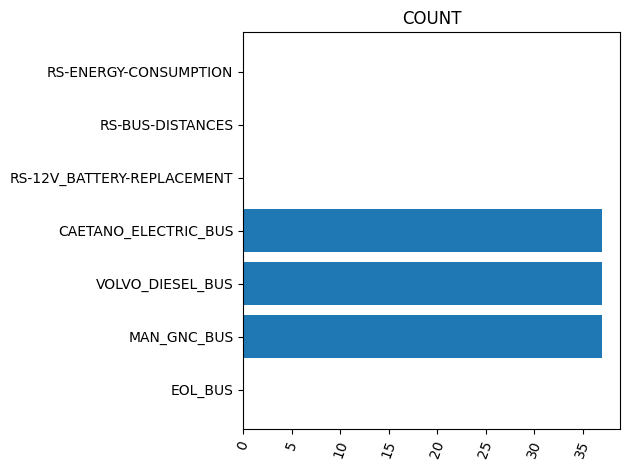

In [73]:
x_data=[]
y_data=[]

print(sources_stats)

for key, source_stats in sources_stats.items():
    x_data.append(key)

    print(key, source_stats)
    
    if source_stats and "count" in source_stats["detail"]["value"]:
        y_data.append(source_stats["detail"]["value"]["count"])
    else:
        y_data.append(0)

    print(x_data[-1], y_data[-1])

plt.barh(x_data, y_data)
plt.title("COUNT")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()


## Stats (NESTED)

In addition to total statistics, the API also supports "nested" statistics.  These can be used to define groups to which statistics are calculated. 

A particular example is when we wish to generate daily, monthly or yearly statistics. 

The below shows several API operation to extract nested statistical data from report sources. It is noted that it is necessary to also indicate the property.

The group that defines the nested criteria is currently based on timeframe.  For example, 
- `group_by="%Y-%m"` generates montly statistics.
- `group_by="%Y-%m-%d"` generates daily statistics.

Statistical operations include: count, sum, min, max, avg.

Timeframe can be specified as well, like start_date and a end_date (format YYYY-MM-DD) or an interval (format int+time-duration e.g., 1y for one year)

NOTE:  the query might be time consuming, in case of timeout try with a shorter timeframe.

In [42]:
# totals (jan only)

#start_date="2025-01-01"
#end_date="2025-01-31"
sources_properties_stats_nested={}
group_by="%Y-%m"
keys="value"
stats="count,avg,max,min"
#
for dr in dataset_report["items"]:
    device_id = dr["source"]["deviceId"]
    sources_properties_stats_nested[device_id]={}
    for prop in source_properties:
        print(device_id, prop)
        endpoint = ENDPOINT_GET_DEVICE_ID_DATA_STATS_NESTED % ( device_id, prop, keys, stats, group_by ) + "&start_date="+start_date+"&end_date="+end_date
        (result, data) = common.get_data(endpoint, token, None)
        sources_properties_stats_nested[device_id][prop]=data
    #print(result, data)
    #print(endpoint)


EOL_BUS bus_diesel_number
-- get from  https://api.cssboost.particle-summary.pt/data-reports/EOL_BUS/data/statistics/nested/date/bus_diesel_number/keys/value?statistics=count,avg,max,min&group_by=%Y-%m&start_date=2023-01-01&end_date=2027-01-01
-- data GET OK.
EOL_BUS bus_gas_number
-- get from  https://api.cssboost.particle-summary.pt/data-reports/EOL_BUS/data/statistics/nested/date/bus_gas_number/keys/value?statistics=count,avg,max,min&group_by=%Y-%m&start_date=2023-01-01&end_date=2027-01-01
-- data GET OK.
EOL_BUS bus_electrical_number
-- get from  https://api.cssboost.particle-summary.pt/data-reports/EOL_BUS/data/statistics/nested/date/bus_electrical_number/keys/value?statistics=count,avg,max,min&group_by=%Y-%m&start_date=2023-01-01&end_date=2027-01-01
-- data GET OK.
EOL_BUS fuel_cost_per_kWh
-- get from  https://api.cssboost.particle-summary.pt/data-reports/EOL_BUS/data/statistics/nested/date/fuel_cost_per_kWh/keys/value?statistics=count,avg,max,min&group_by=%Y-%m&start_date=2023-

In [43]:
def chart_nested_stats(title, data_stats):
    #
    if data_stats and "count" in data_stats["value"]:
        x_values=list(data_stats["value"]["count"].keys())
        count_values=list(data_stats["value"]["count"].values())
        plt.subplot(1,2,1)
        plt.bar(x_values, count_values)
        plt.title(title+" COUNT", fontsize=8)
        plt.xticks(rotation=70)
        plt.tight_layout()
    #    
    if data_stats and "avg" in data_stats["value"]:    
        x_values=list(data_stats["value"]["avg"].keys())
        avg_values=[float(v) for v in data_stats["value"]["avg"].values()] #list(data_stats["value"]["avg"].values())
        max_values=[float(v) for v in data_stats["value"]["max"].values()] #list(data_stats["value"]["max"].values())
        min_values=[float(v) for v in data_stats["value"]["min"].values()] #list(data_stats["value"]["min"].values())
        plt.subplot(1,2,2)
        plt.plot(x_values, avg_values)
        plt.plot(x_values, min_values)
        plt.plot(x_values, max_values)
        plt.title(title+" STATS", fontsize=8)
        plt.xticks(rotation=70)
 
    plt.tight_layout()
    plt.show()
        

EOL_BUS


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

MAN_GNC_BUS


<Figure size 640x480 with 0 Axes>

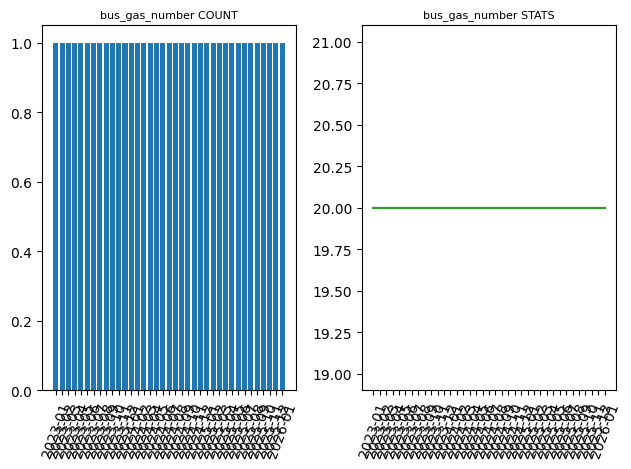

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

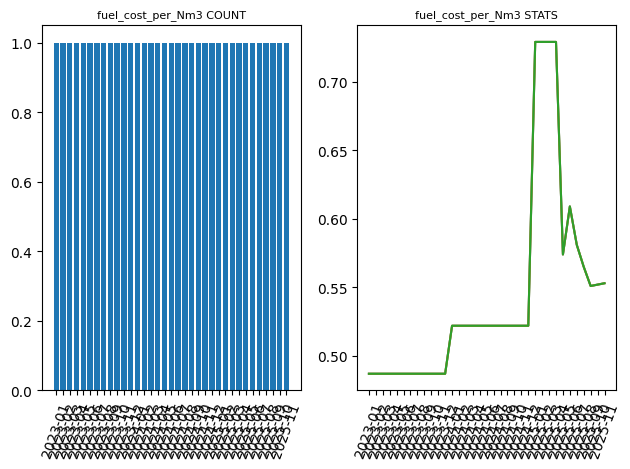

<Figure size 640x480 with 0 Axes>

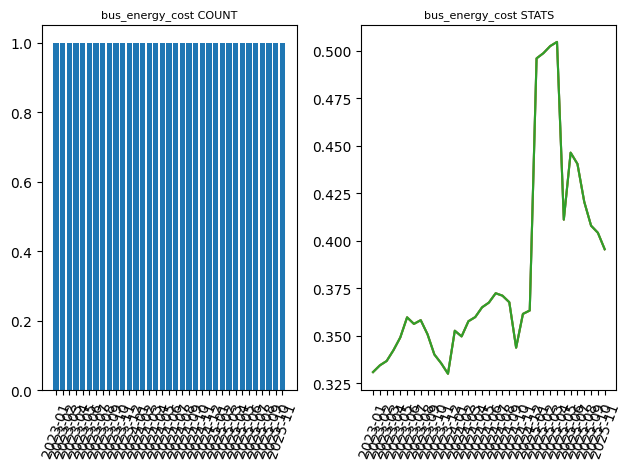

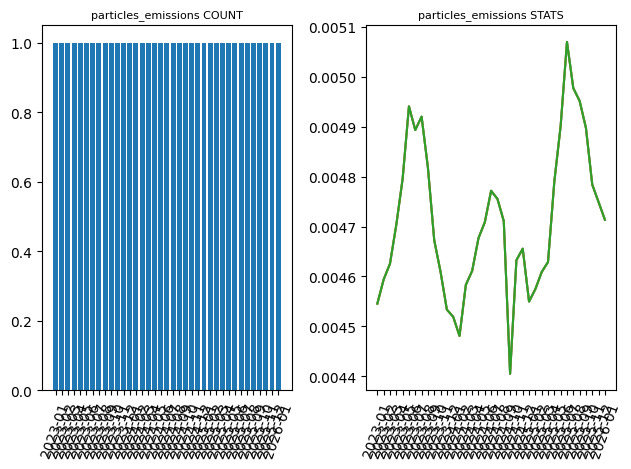

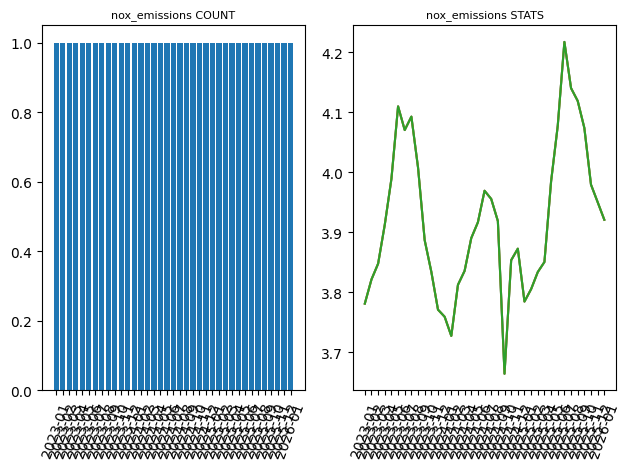

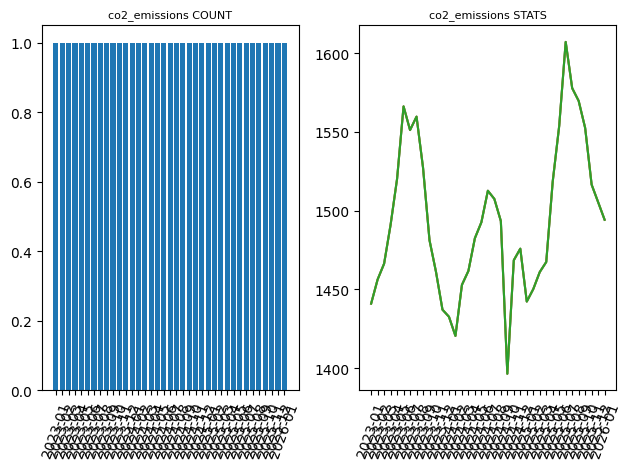

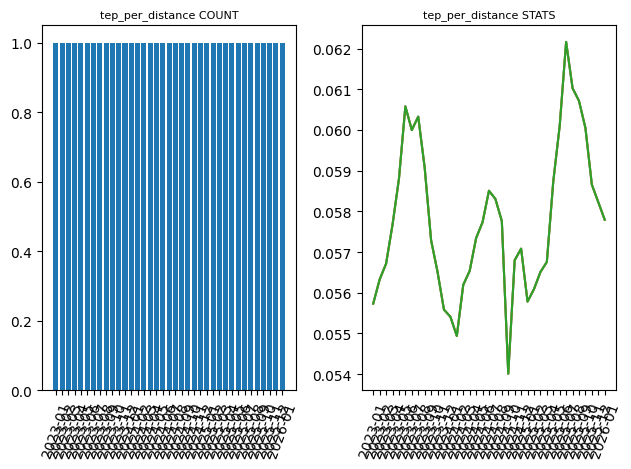

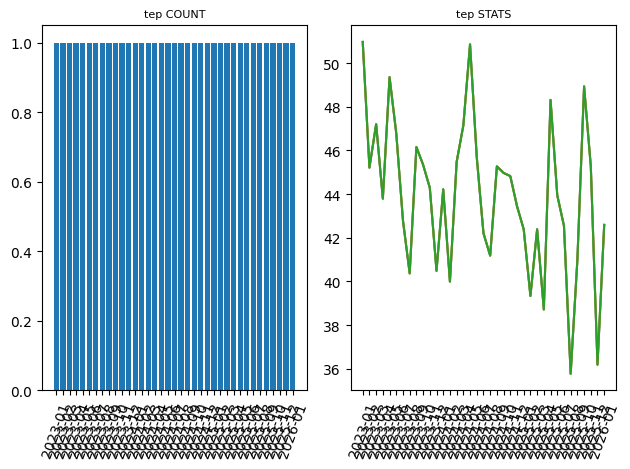

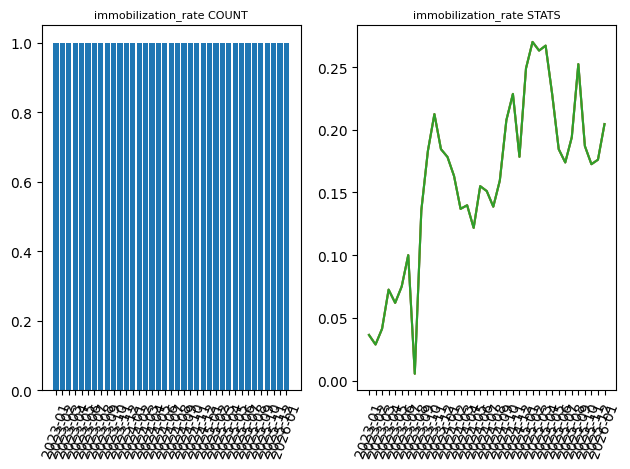

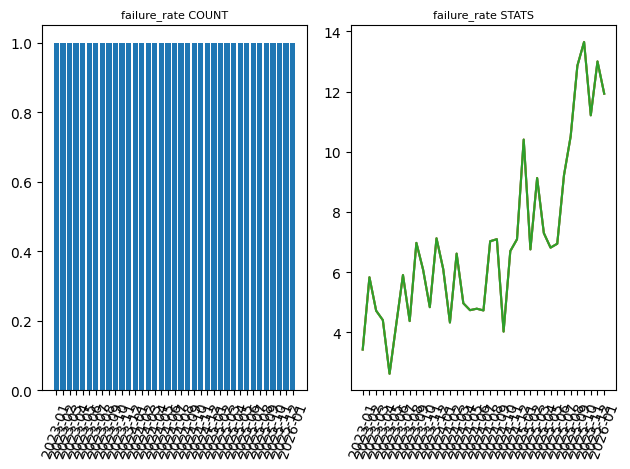

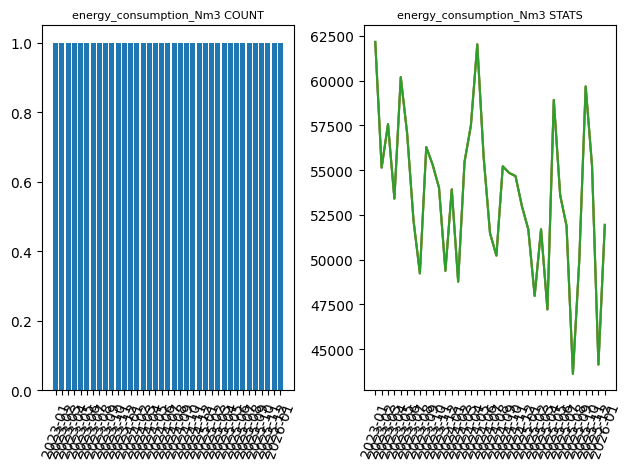

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

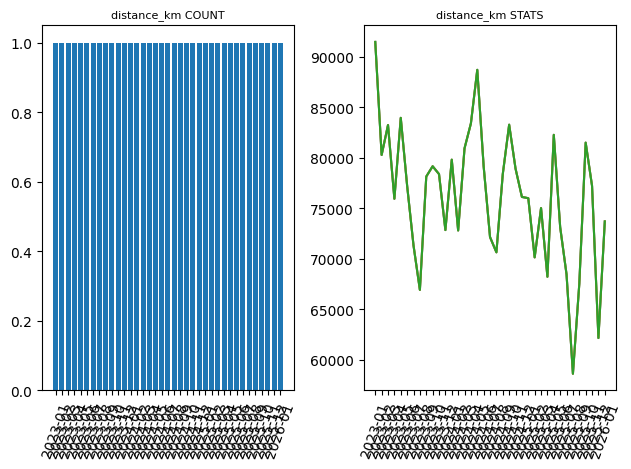

VOLVO_DIESEL_BUS


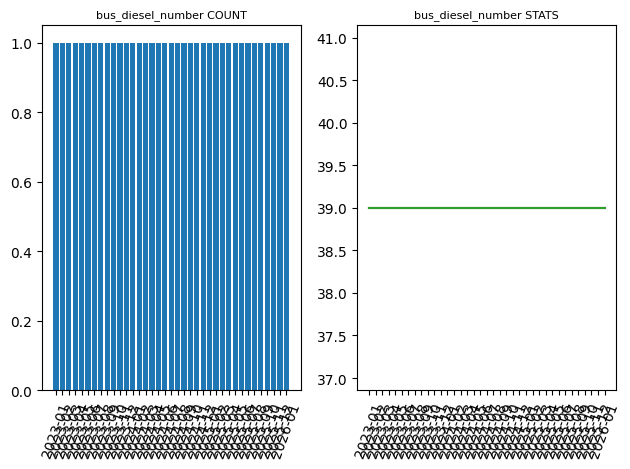

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

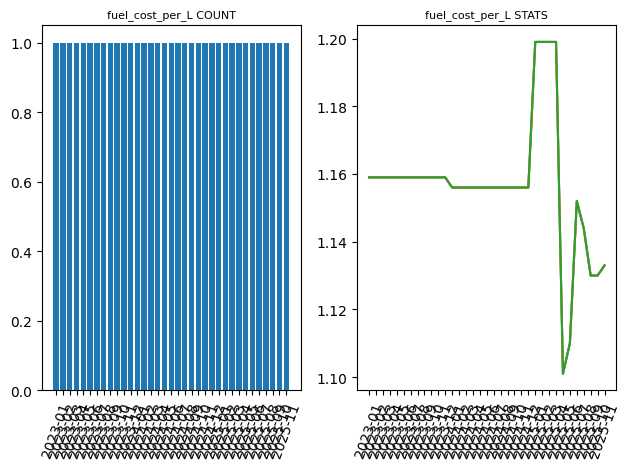

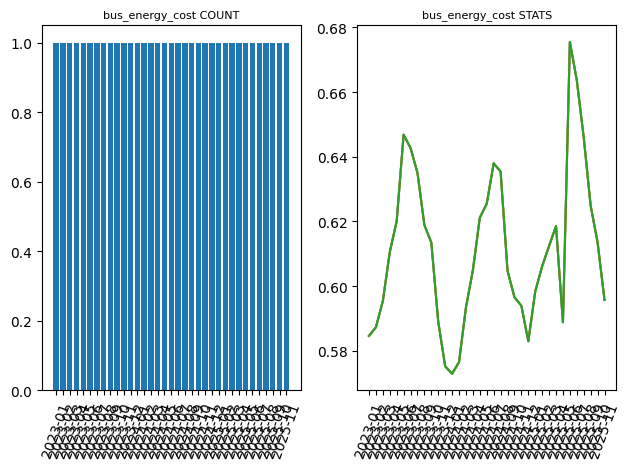

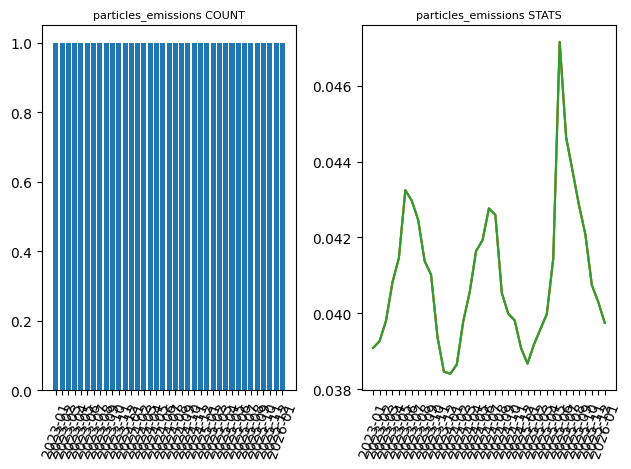

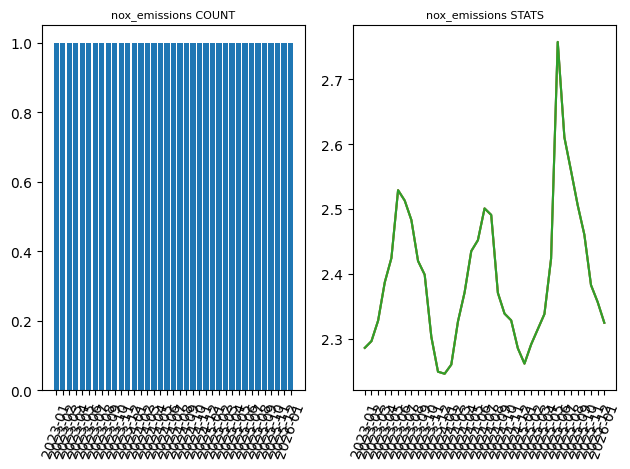

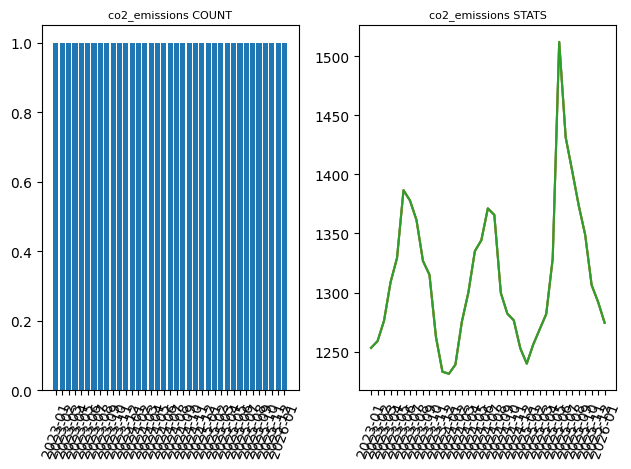

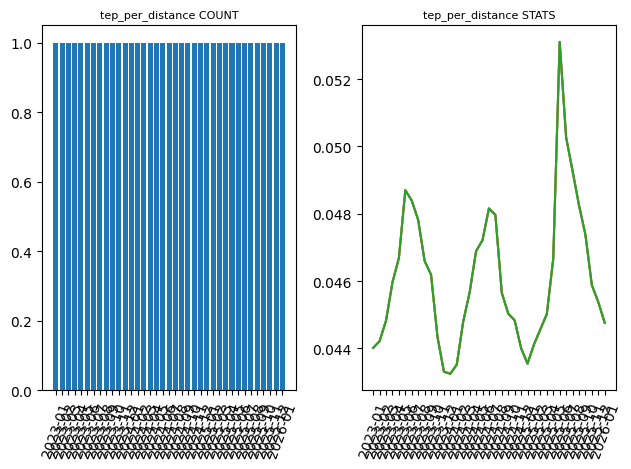

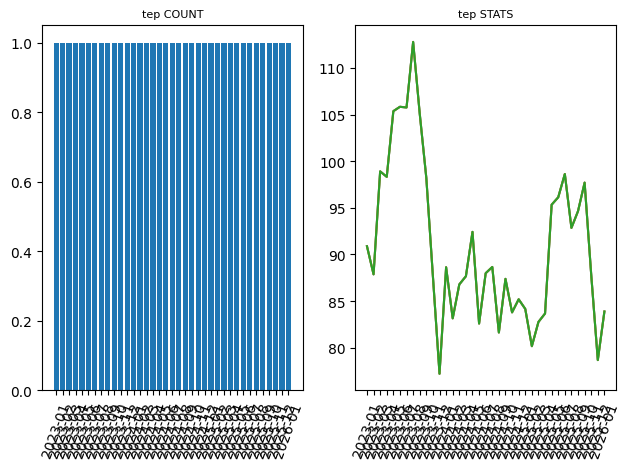

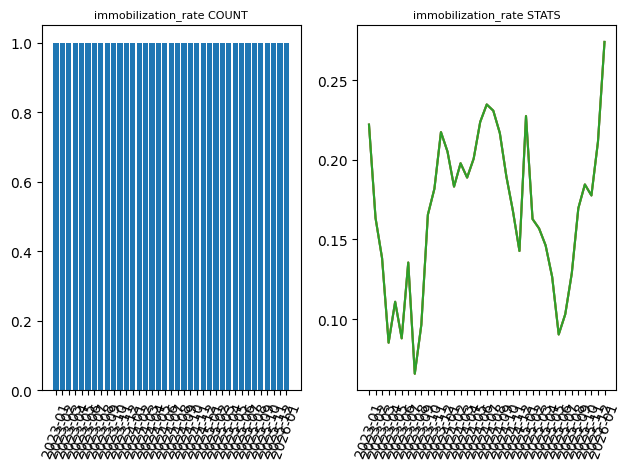

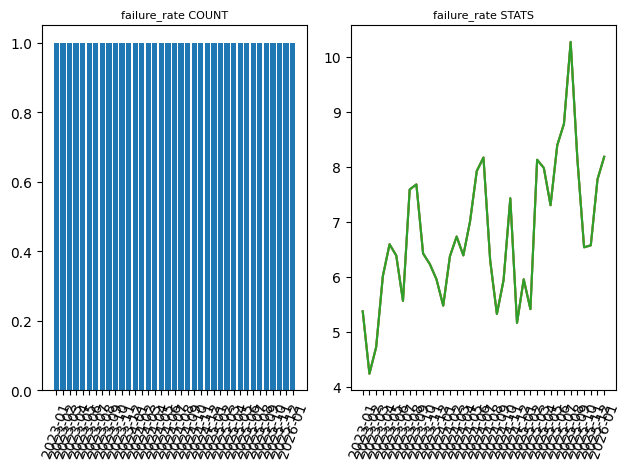

<Figure size 640x480 with 0 Axes>

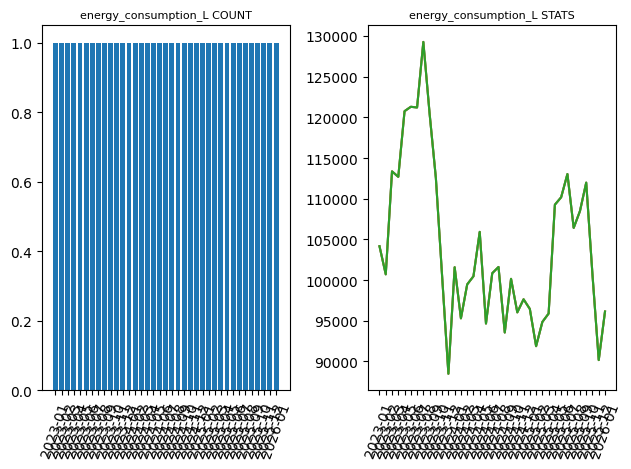

<Figure size 640x480 with 0 Axes>

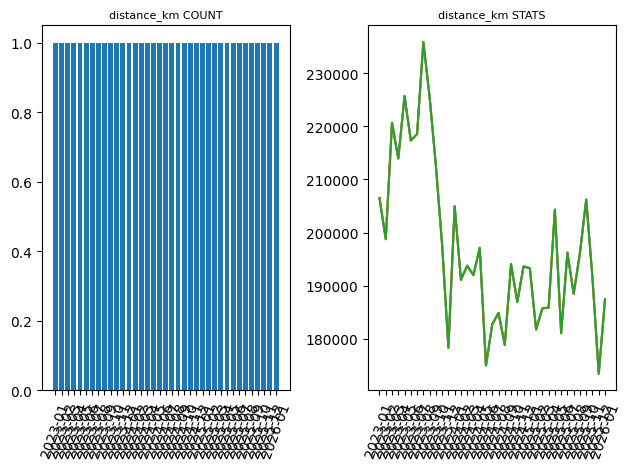

CAETANO_ELECTRIC_BUS


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

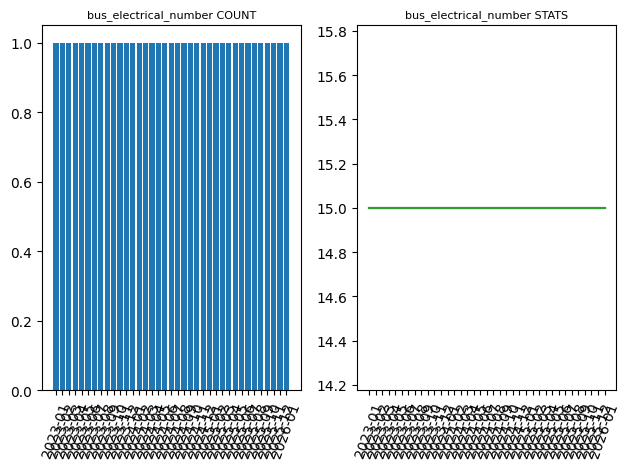

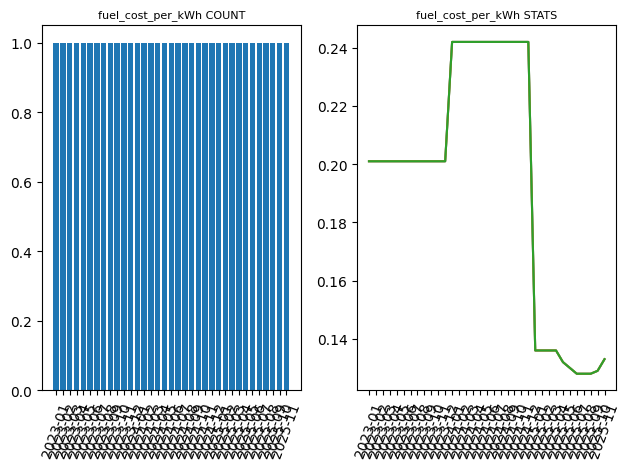

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

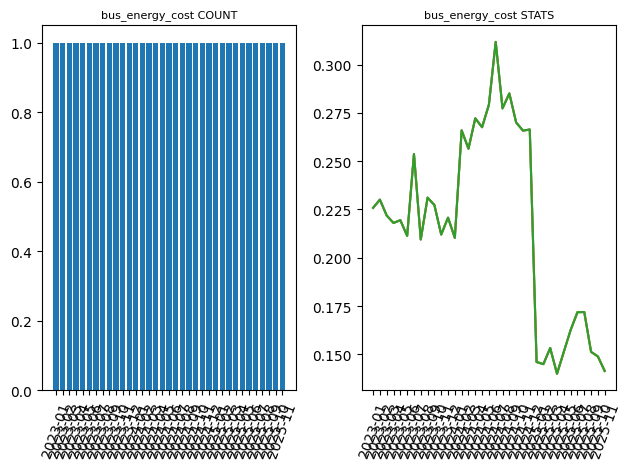

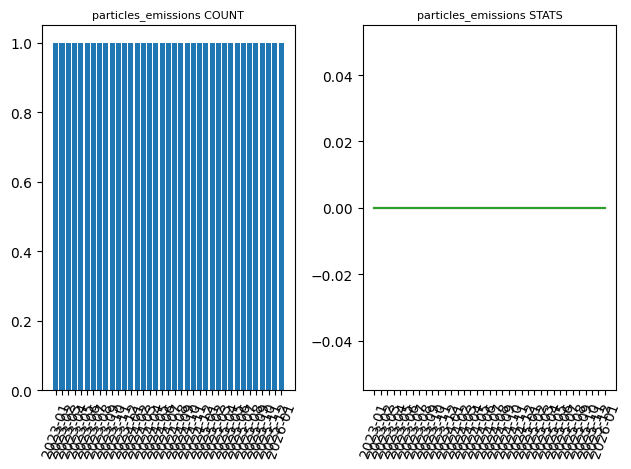

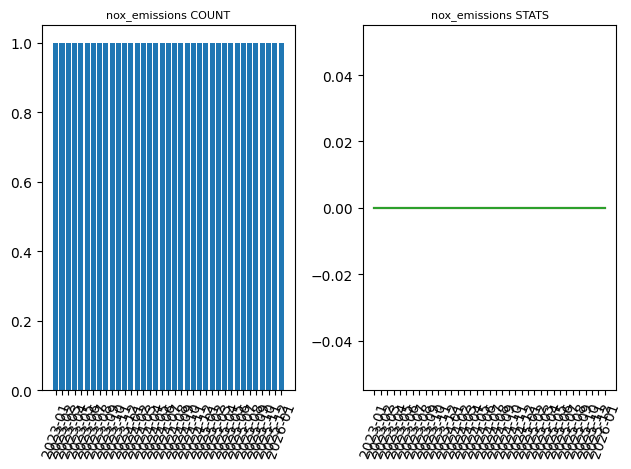

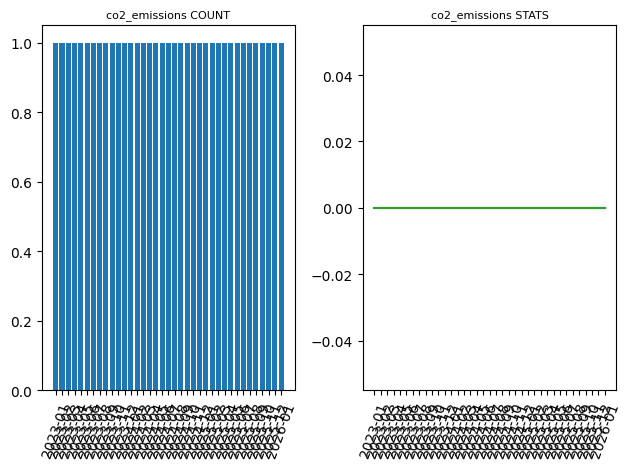

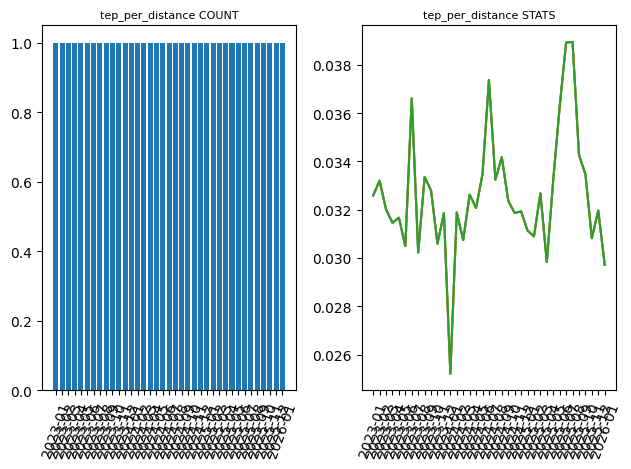

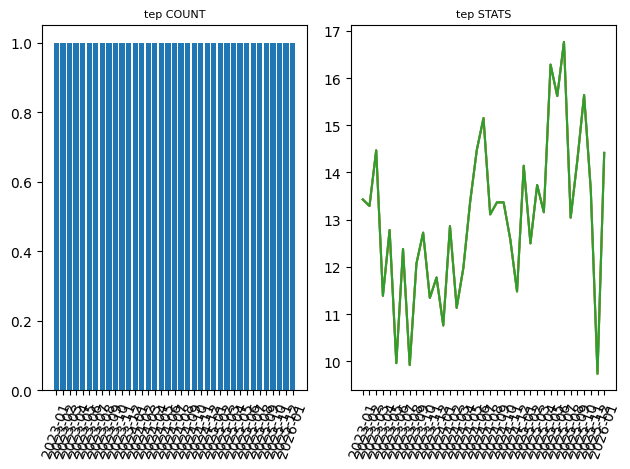

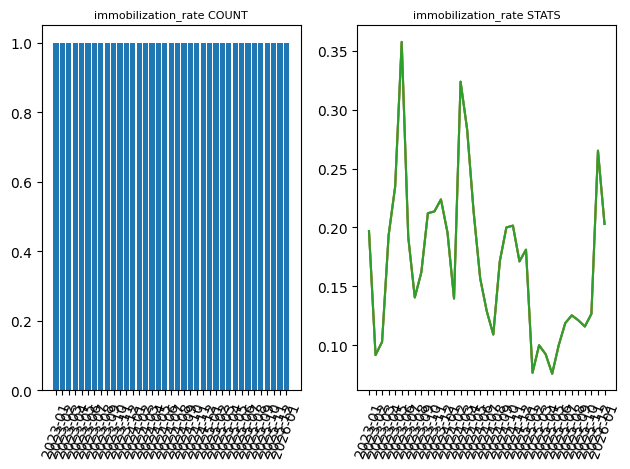

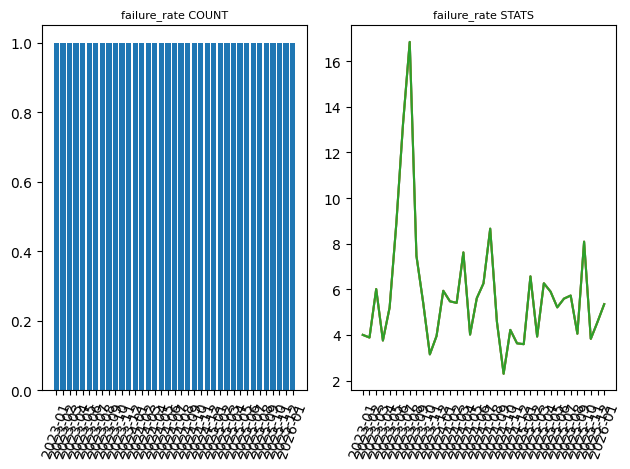

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

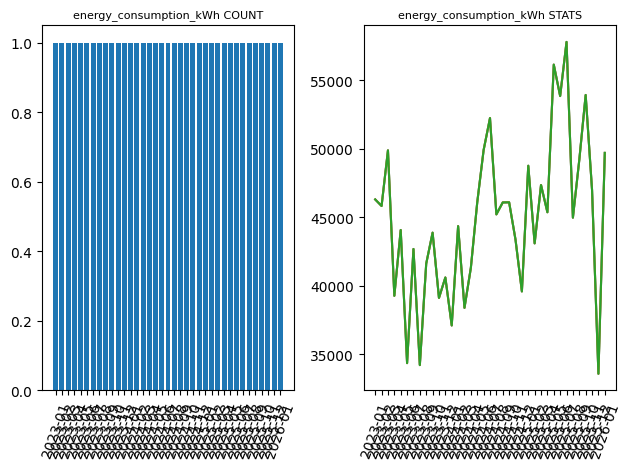

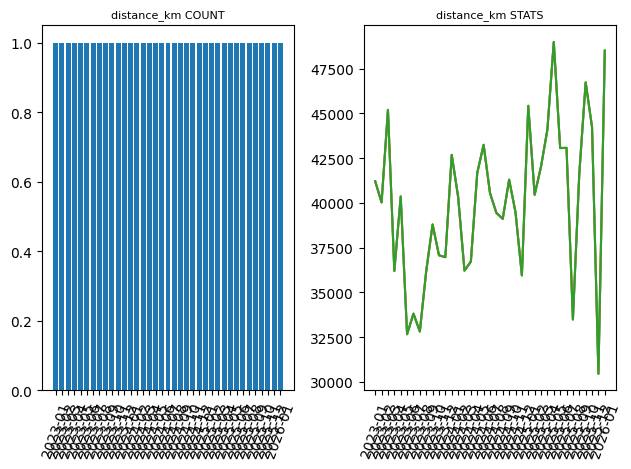

RS-12V_BATTERY-REPLACEMENT


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [44]:
# parse all sources
for source, source_stats_nested in sources_properties_stats_nested.items():
    print(source)
    for prop, stats_nested in source_stats_nested.items():
        #print(prop, stats_nested)
        chart_nested_stats(prop, stats_nested)
